In [1]:
import utils_FaIR_JAX
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
import pickle

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

# Generate GeoMIP inputs with inverse model
Here, we use the inverse capability of the JAX SCM to make a version of one of the GeoMIP scenarios (G6-sulfur). We want to calculate the required level of sulfur injection to cool the high emissions scenario to be equivalent to that of the medium emissions scenario.

Because our SCM calculates sulfur's radiative forcing contribution as parameterized aerosol-cloud interactions, the sulfur emissions of the GeoMIP analogue are much larger than the true GeoMIP protocol (i.e., unrealistic) and instead serve as a strongly out-of-distribution test for the emulator.

In [3]:
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_H = jnp.concatenate([emis_dict_calib_JAX['historical'], emis_dict_calib_JAX['H-ext']], axis=1)
emis_M = jnp.concatenate([emis_dict_calib_JAX['historical'], emis_dict_calib_JAX['M-ext']], axis=1)

T = emis_H.shape[1]
years = jnp.arange(T, dtype=jnp.float32)
delT_M = utils_FaIR_JAX.simulate_temp(years, emis_M)['GMST']

In [18]:
# Use inverse model to generate sulfur injection profile
opt_sulfur, final_T_pred = utils_FaIR_JAX.solve_sulfur_inverse(
    emis_H,
    delT_M,
    years,
    learning_rate=0.8,
    n_steps=4000,
    reg_weight=1e-4)


Starting Inverse Solve (Target: M Temp, Background: H Emis)...
Step 0: Loss = 7.127846
Step 200: Loss = 2.926804
Step 400: Loss = 1.927964
Step 600: Loss = 1.370041
Step 800: Loss = 1.000175
Step 1000: Loss = 0.736923
Step 1200: Loss = 0.543180
Step 1400: Loss = 0.398345
Step 1600: Loss = 0.289451
Step 1800: Loss = 0.207663
Step 2000: Loss = 0.146624
Step 2200: Loss = 0.101570
Step 2400: Loss = 0.068824
Step 2600: Loss = 0.045495
Step 2800: Loss = 0.029262
Step 3000: Loss = 0.018284
Step 3200: Loss = 0.011101
Step 3400: Loss = 0.006569
Step 3600: Loss = 0.003823
Step 3800: Loss = 0.002235
Final Loss: 0.001361


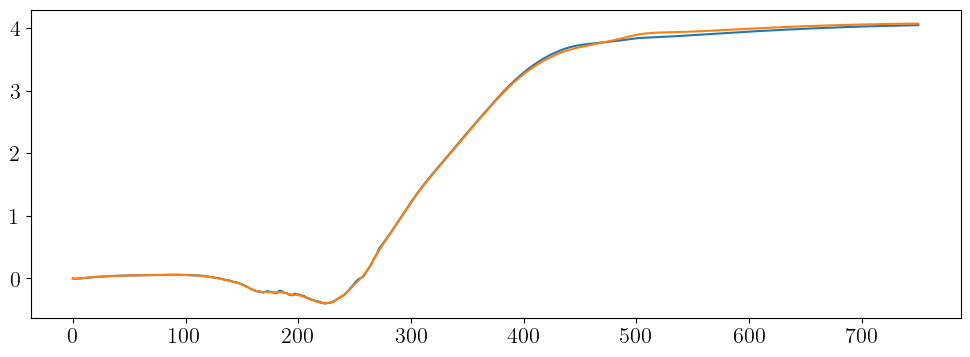

In [19]:
# Plot temperature time series
plt.plot(delT_M)
plt.plot(final_T_pred)

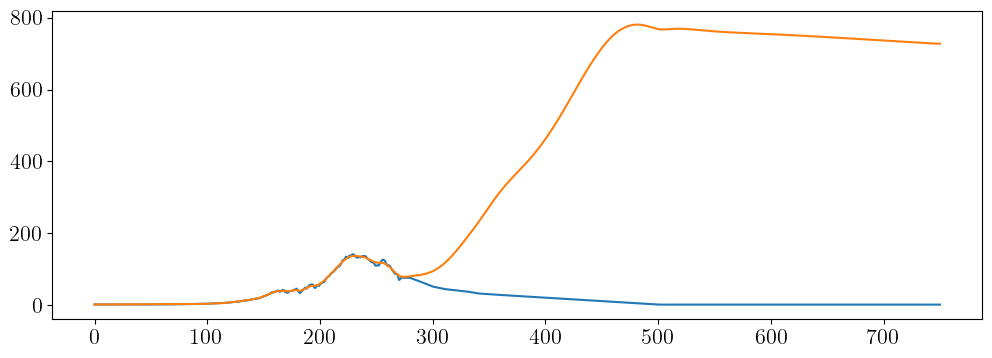

In [20]:
# Plot emissions time series
plt.plot(emis_M[3,:])
plt.plot(opt_sulfur)

In [37]:
# Create full emissions dataset
emis_H_G6 = np.concatenate([emis_dict_calib_JAX['historical'], emis_dict_calib_JAX['H-ext']], axis=1).copy()
emis_H_G6[3,:] = opt_sulfur.copy()

# Save emissions data
path = 'data/GeoMIP/emis_G6sulfur.pickle'
with open(path, "wb") as f:
        pickle.dump(emis_H_G6, f)